In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [10]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Cell2data.csv')

In [5]:
data

,Date,AVG_NO_USER,AVG_USR_THRPUT_DL,DL_TRAFFIC_MB
0,9/1/2022 0:00,3.15,1.91,7352.15
1,9/2/2022 0:00,3.05,1.91,6670.40
2,9/3/2022 0:00,2.84,1.85,6741.95
3,9/4/2022 0:00,2.88,1.97,6852.46
4,9/5/2022 0:00,2.82,1.67,6044.27
...,...,...,...,...
361,8/28/2023 0:00,17.78,3.30,42125.39
362,8/29/2023 0:00,19.08,3.43,37329.86
363,8/30/2023 0:00,21.10,3.25,39321.38
364,8/31/2023 0:00,19.00,2.65,41141.22


Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.02704441276673586
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.02704441276673586
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.02849183877871394
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.02849183877871394
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.02777968649880568
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.02777968649880568
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.057627309725893
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.030176900450274755
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.051338854972972844
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.028633949366386666
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.04111108475755631
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.03045942835600449
Tra

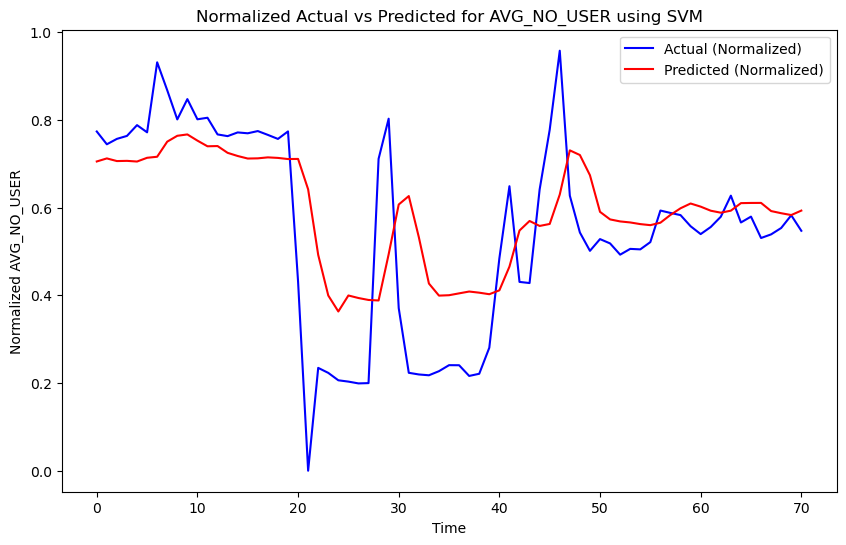

In [11]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.08925200242040073
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.08925200242040073
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.08925200242040073
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.08925200242040073
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.08925200242040073
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.08925200242040073
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.08925200242040073
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.08925200242040073
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.08925200242040073
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.08925200242040073
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.08925200242040073
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.08925200242040073
Trai

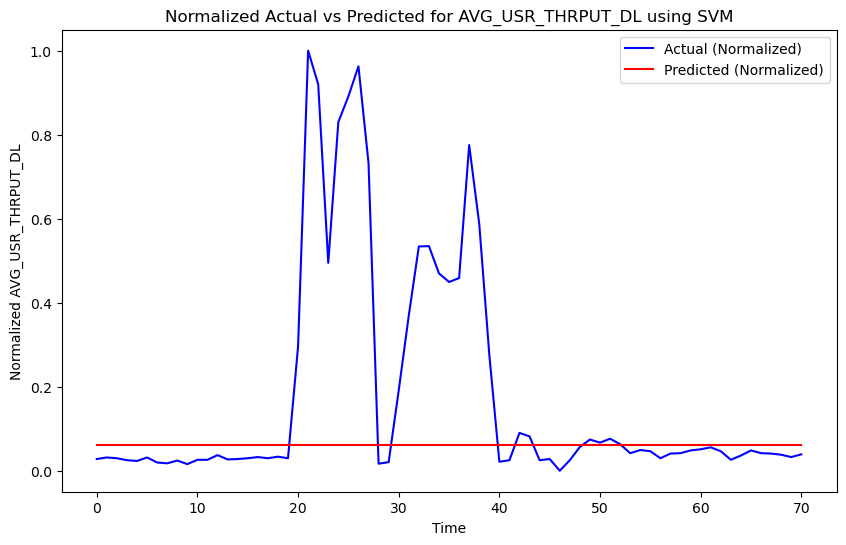

In [12]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.019198311703226178
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.019198311703226178
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.014441556454136383
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.014441556454136383
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.01443621696850211
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.01443621696850211
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.02340454149583521
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.020672970845188644
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.023644919925873434
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.012516300742333284
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.023726015333360165
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.01181780903439

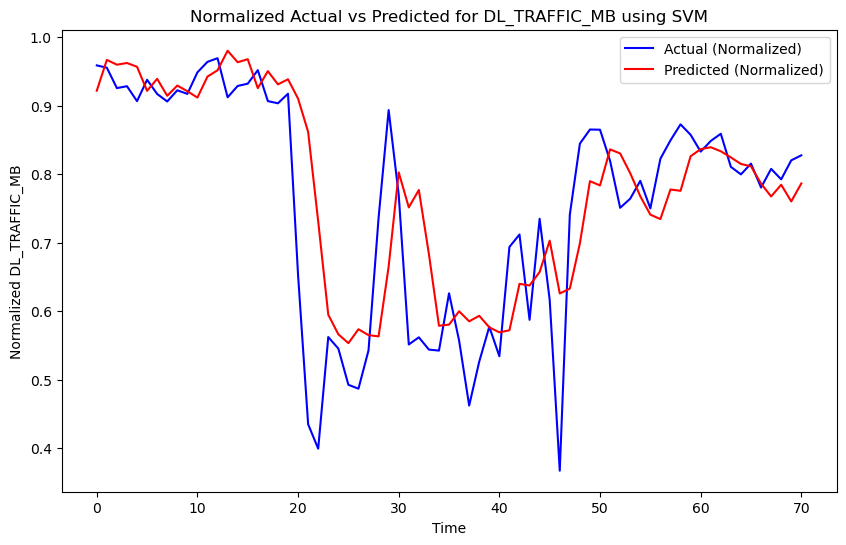

In [13]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [47]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]


Epoch 1/50
9/9 [==============================] - 13s 173ms/step - loss: 0.1185 - val_loss: 0.0192
Epoch 2/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0281 - val_loss: 0.0011
Epoch 3/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0074 - val_loss: 0.0133
Epoch 4/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0053 - val_loss: 0.0011
Epoch 5/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0044 - val_loss: 0.0013
Epoch 6/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 7/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 8/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 9/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 10/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 11/50
9/9 [==========

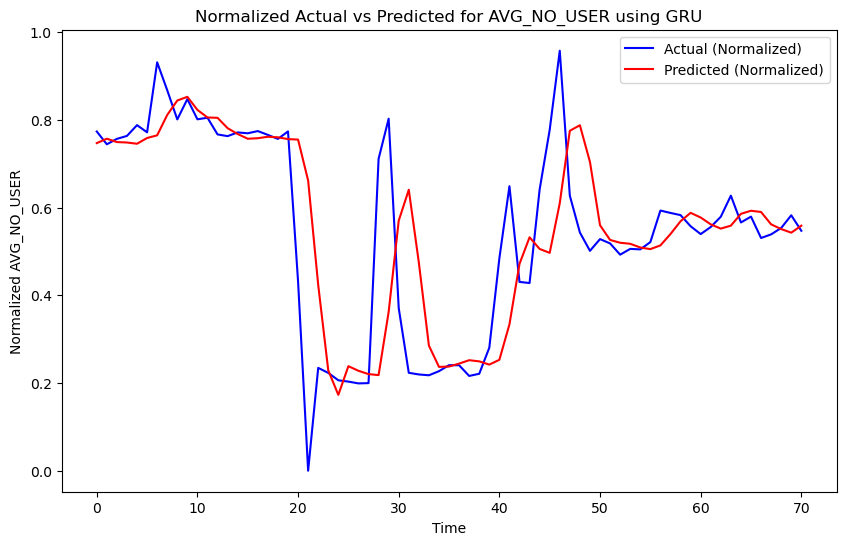

In [48]:
# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 7s 143ms/step - loss: 0.0015 - val_loss: 4.1094e-04
Epoch 2/50
9/9 [==============================] - 0s 18ms/step - loss: 8.3034e-04 - val_loss: 1.5362e-04
Epoch 3/50
9/9 [==============================] - 0s 14ms/step - loss: 5.5727e-04 - val_loss: 2.0131e-04
Epoch 4/50
9/9 [==============================] - 0s 12ms/step - loss: 3.8051e-04 - val_loss: 1.1024e-04
Epoch 5/50
9/9 [==============================] - 0s 13ms/step - loss: 2.2817e-04 - val_loss: 8.9909e-05
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 1.7261e-04 - val_loss: 7.0289e-05
Epoch 7/50
9/9 [==============================] - 0s 13ms/step - loss: 1.3092e-04 - val_loss: 7.4777e-05
Epoch 8/50
9/9 [==============================] - 0s 12ms/step - loss: 1.5789e-04 - val_loss: 7.4856e-05
Epoch 9/50
9/9 [==============================] - 0s 13ms/step - loss: 1.5416e-04 - val_loss: 7.4597e-05
Epoch 10/50
9/9 [==============================] - 0s 12ms

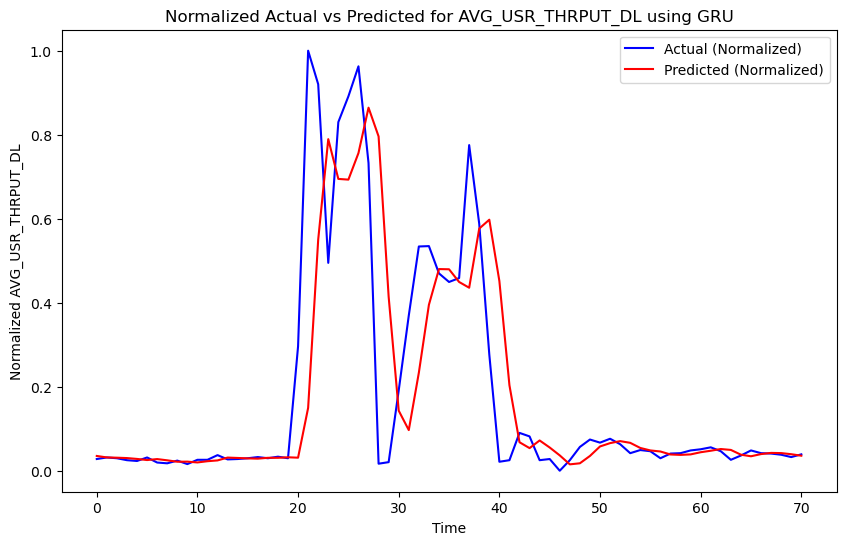

In [49]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 8s 192ms/step - loss: 0.3634 - val_loss: 0.0186
Epoch 2/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0348 - val_loss: 0.0380
Epoch 3/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0207 - val_loss: 0.0083
Epoch 4/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0147 - val_loss: 0.0068
Epoch 5/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0085 - val_loss: 0.0012
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0086 - val_loss: 7.0488e-04
Epoch 7/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0076 - val_loss: 0.0015
Epoch 8/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0076 - val_loss: 5.4746e-04
Epoch 9/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0074 - val_loss: 9.8965e-04
Epoch 10/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0076 - val_loss: 8.1449e-04
Epoch 11/50


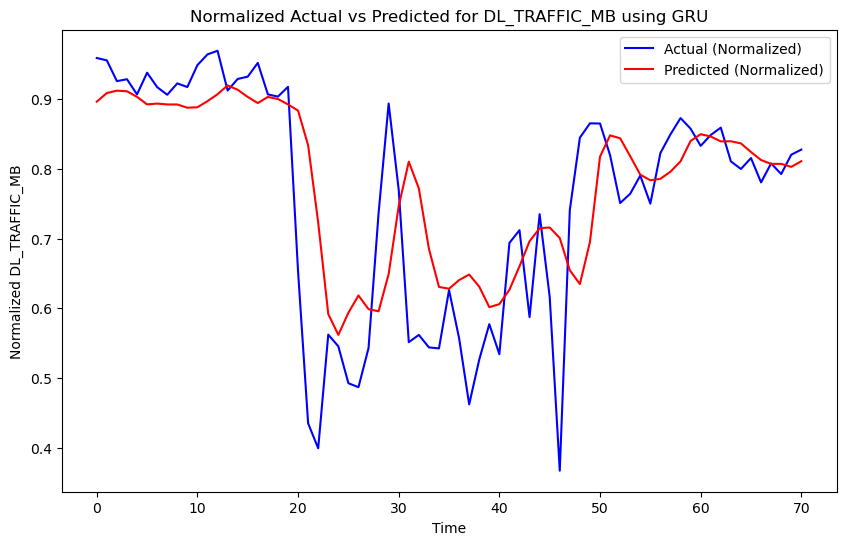

In [50]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [53]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Epoch 1/50
9/9 [==============================] - 7s 199ms/step - loss: 0.3143 - val_loss: 0.2277
Epoch 2/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0811 - val_loss: 0.0012
Epoch 3/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0235 - val_loss: 0.0074
Epoch 4/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0066 - val_loss: 0.0149
Epoch 5/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0083 - val_loss: 0.0042
Epoch 6/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0037 - val_loss: 0.0011
Epoch 7/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0039 - val_loss: 0.0024
Epoch 8/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0037 - val_loss: 0.0020
Epoch 9/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0034 - val_loss: 0.0014
Epoch 10/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0035 - val_loss: 0.0021
Epoch 11/50
9/9 [===========

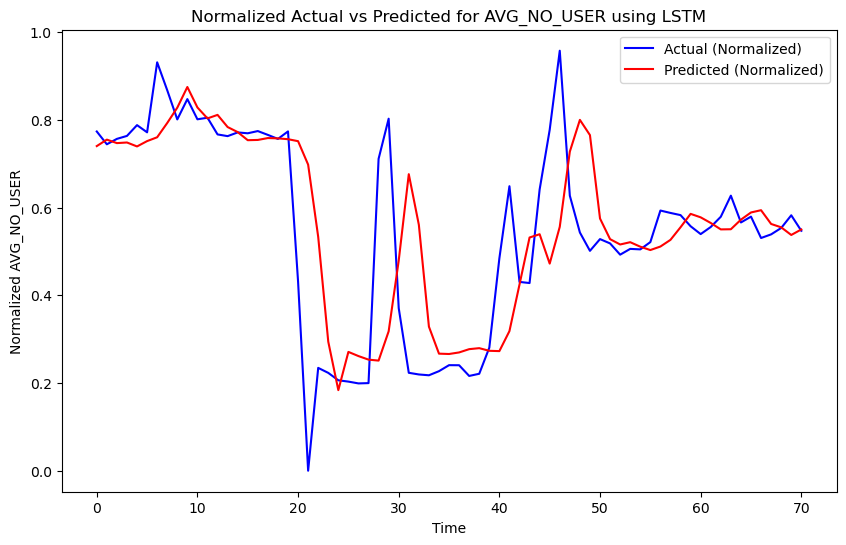

In [54]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 7s 161ms/step - loss: 0.0018 - val_loss: 9.3986e-04
Epoch 2/50
9/9 [==============================] - 0s 14ms/step - loss: 8.2316e-04 - val_loss: 2.1982e-04
Epoch 3/50
9/9 [==============================] - 0s 15ms/step - loss: 6.6995e-04 - val_loss: 2.3274e-04
Epoch 4/50
9/9 [==============================] - 0s 15ms/step - loss: 5.5826e-04 - val_loss: 2.3588e-04
Epoch 5/50
9/9 [==============================] - 0s 17ms/step - loss: 4.5447e-04 - val_loss: 1.7675e-04
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 3.3629e-04 - val_loss: 1.4193e-04
Epoch 7/50
9/9 [==============================] - 0s 13ms/step - loss: 2.2126e-04 - val_loss: 9.6128e-05
Epoch 8/50
9/9 [==============================] - 0s 13ms/step - loss: 1.9736e-04 - val_loss: 9.2571e-05
Epoch 9/50
9/9 [==============================] - 0s 15ms/step - loss: 1.7722e-04 - val_loss: 1.5260e-04
Epoch 10/50
9/9 [==============================] - 0s 14ms

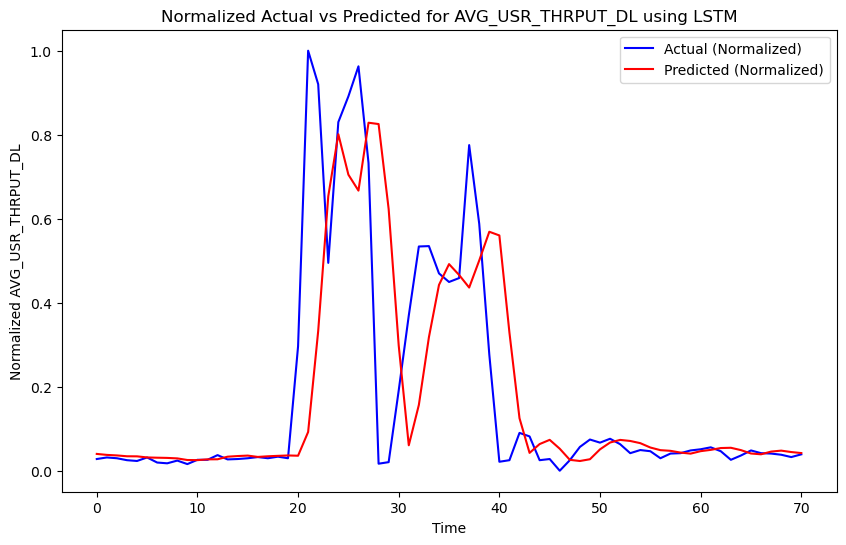

In [55]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 10s 175ms/step - loss: 0.5190 - val_loss: 0.3127
Epoch 2/50
9/9 [==============================] - 0s 14ms/step - loss: 0.1380 - val_loss: 8.8608e-04
Epoch 3/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0323 - val_loss: 0.0213
Epoch 4/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0136 - val_loss: 0.0095
Epoch 5/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0138 - val_loss: 0.0035
Epoch 6/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0081 - val_loss: 0.0013
Epoch 7/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0077 - val_loss: 0.0011
Epoch 8/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0071 - val_loss: 0.0014
Epoch 9/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0070 - val_loss: 5.5456e-04
Epoch 10/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0069 - val_loss: 0.0012
Epoch 11/50
9/9 [==

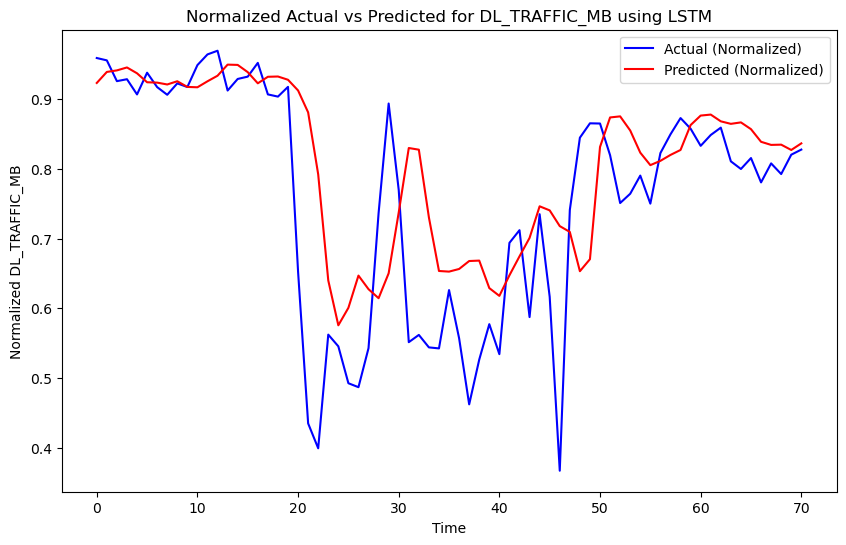

In [56]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [57]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


ARIMA Model MSE (Normalized): 0.0756138873235272


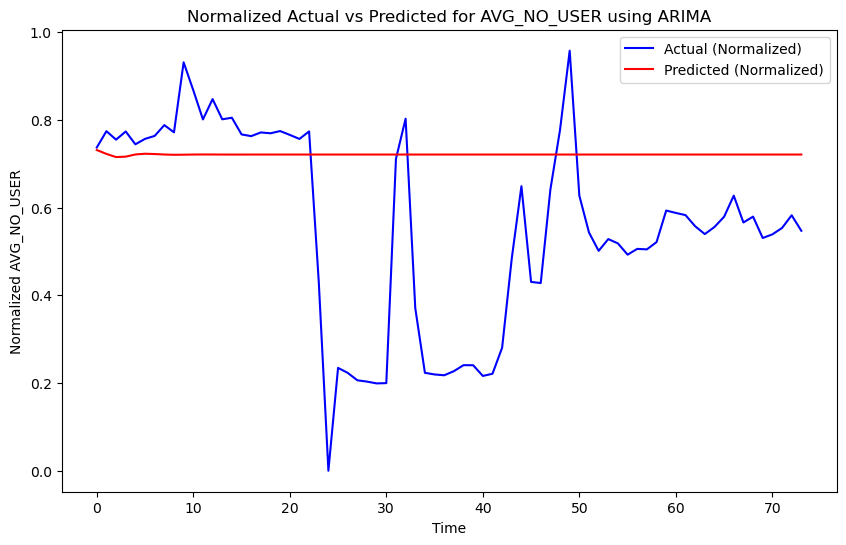

In [59]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Cell2data.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import matplotlib.pyplot as plt

In [28]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Cell3data.csv')

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA Model MSE (Normalized) for AVG_USR_THRPUT_DL: 0.12285766237628129


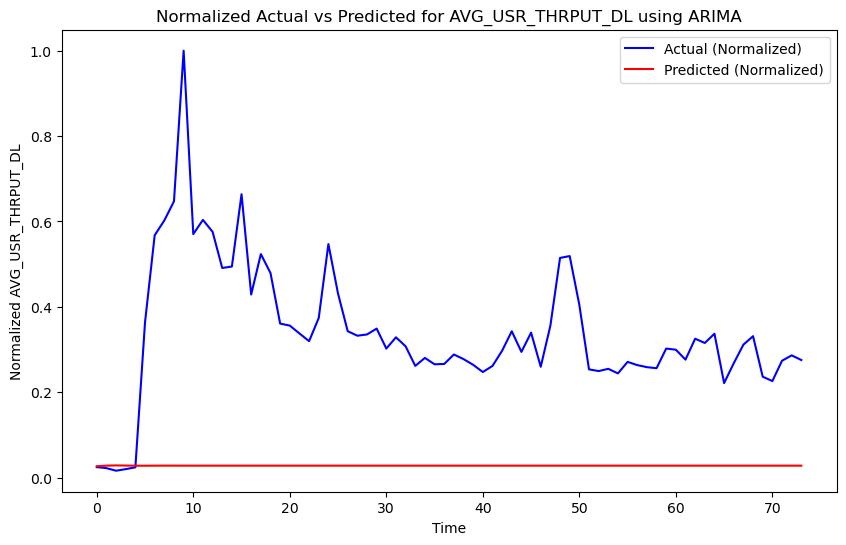

In [39]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Cell5data.csv')

# Preparing data for 'AVG_USR_THRPUT_DL'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'AVG_USR_THRPUT_DL' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])



# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized) for {feature}: {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

ARIMA Model MSE (Normalized) for DL_TRAFFIC_MB: 0.05936615366578203


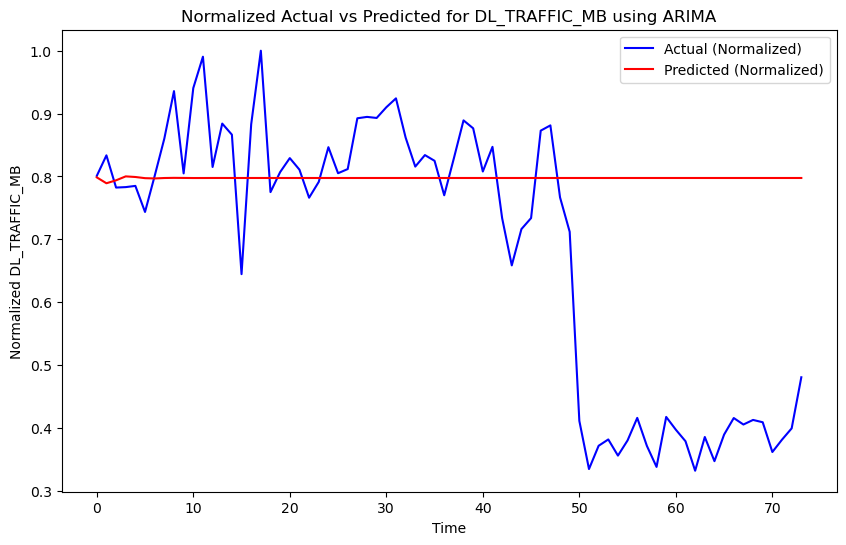

In [19]:
# Preparing data for 'AVG_USR_THRPUT_DL'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'AVG_USR_THRPUT_DL' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized) for {feature}: {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [15]:
data

,Date,AVG_NO_USER,AVG_USR_THRPUT_DL,DL_TRAFFIC_MB
0,2022-09-01 00:00:00,92.47,1.28,245715.83
1,2022-09-02 00:00:00,96.59,1.28,239054.76
2,2022-09-03 00:00:00,94.34,1.26,227404.31
3,2022-09-04 00:00:00,98.13,1.22,250540.36
4,2022-09-05 00:00:00,96.13,1.19,235684.06
...,...,...,...,...
361,2023-08-28 00:00:00,94.14,0.92,248354.62
362,2023-08-29 00:00:00,95.61,0.91,256585.59
363,2023-08-30 00:00:00,98.19,0.88,251971.19
364,2023-08-31 00:00:00,103.33,0.82,260353.03


In [17]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout
import matplotlib.pyplot as plt

In [23]:

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Normalize the data using MaxAbsScaler between -1 and 1
scaler = MaxAbsScaler()
scaled_data = scaler.fit_transform(data[['AVG_NO_USER']])


Epoch 1/50
9/9 [==============================] - 8s 147ms/step - loss: 0.1476 - val_loss: 0.0159
Epoch 2/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0374 - val_loss: 9.5350e-04
Epoch 3/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0073 - val_loss: 0.0195
Epoch 4/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0091 - val_loss: 8.6536e-04
Epoch 5/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0051 - val_loss: 5.4243e-04
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0041 - val_loss: 0.0034
Epoch 7/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0038 - val_loss: 0.0014
Epoch 8/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 9/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0037 - val_loss: 7.8495e-04
Epoch 10/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0033 - val_loss: 5.0540e-04
Epoch 11/50

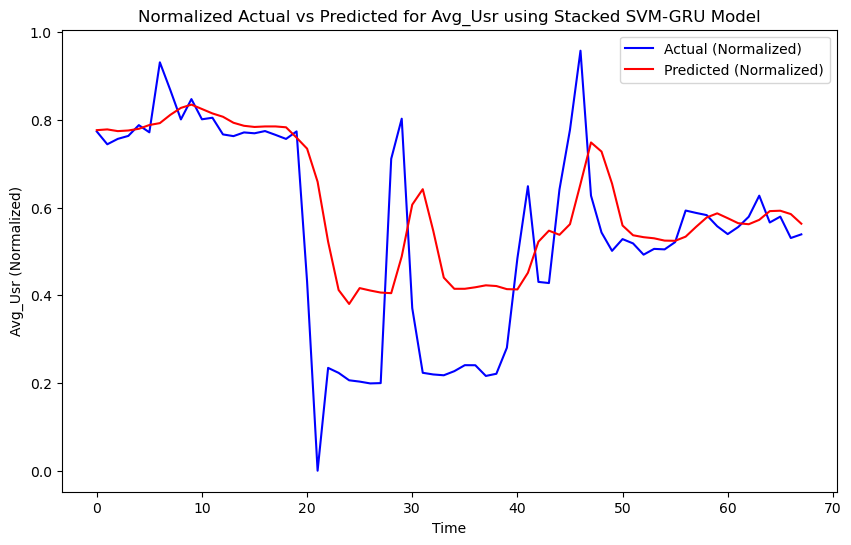

In [30]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 12s 249ms/step - loss: 0.2586 - val_loss: 0.0158
Epoch 2/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0528 - val_loss: 0.0062
Epoch 3/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0148 - val_loss: 0.0199
Epoch 4/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0171 - val_loss: 3.6466e-04
Epoch 5/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0097 - val_loss: 4.7465e-04
Epoch 6/50
9/9 [==============================] - 0s 35ms/step - loss: 0.0118 - val_loss: 0.0110
Epoch 7/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0110 - val_loss: 0.0010
Epoch 8/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0092 - val_loss: 3.2736e-04
Epoch 9/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0075 - val_loss: 9.9125e-04
Epoch 10/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0076 - val_loss: 2.5992e-04
Epoch 1

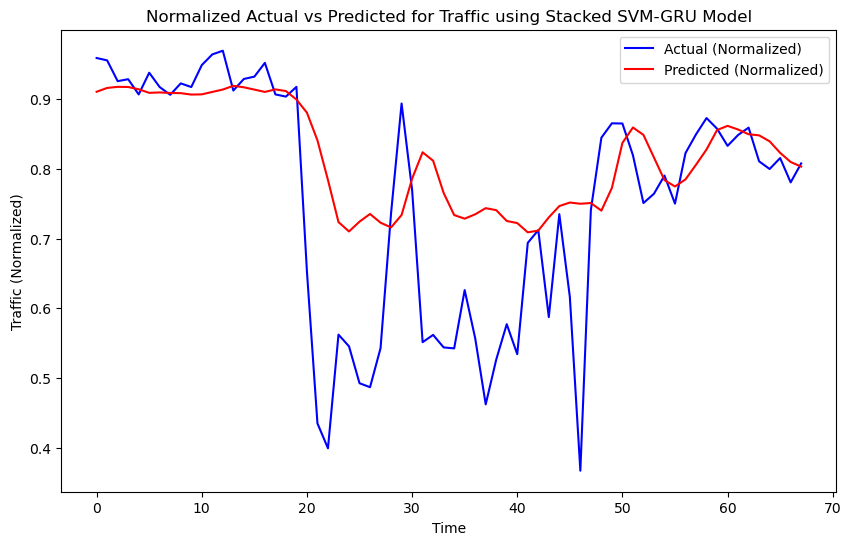

In [44]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Traffic using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Traffic (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 12s 274ms/step - loss: 0.0013 - val_loss: 1.5733e-04
Epoch 2/50
9/9 [==============================] - 0s 26ms/step - loss: 7.3632e-04 - val_loss: 3.9932e-04
Epoch 3/50
9/9 [==============================] - 0s 18ms/step - loss: 4.8342e-04 - val_loss: 6.3377e-05
Epoch 4/50
9/9 [==============================] - 0s 18ms/step - loss: 3.5017e-04 - val_loss: 6.1013e-04
Epoch 5/50
9/9 [==============================] - 0s 20ms/step - loss: 4.4151e-04 - val_loss: 2.3199e-04
Epoch 6/50
9/9 [==============================] - 0s 21ms/step - loss: 2.3672e-04 - val_loss: 1.0170e-04
Epoch 7/50
9/9 [==============================] - 0s 18ms/step - loss: 1.6376e-04 - val_loss: 7.1150e-05
Epoch 8/50
9/9 [==============================] - 0s 22ms/step - loss: 1.8070e-04 - val_loss: 1.0504e-04
Epoch 9/50
9/9 [==============================] - 0s 18ms/step - loss: 1.8011e-04 - val_loss: 6.2279e-05
Epoch 10/50
9/9 [==============================] - 0s 19m

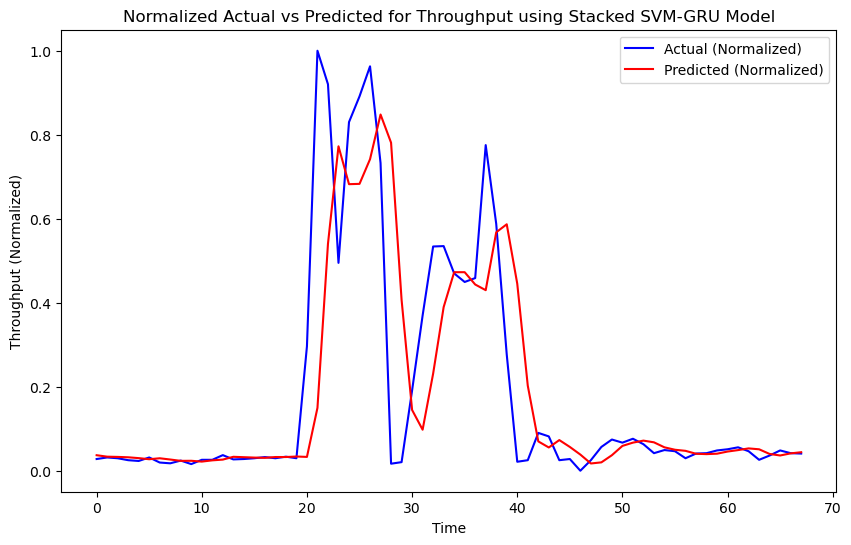

In [46]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Throughput using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Throughput (Normalized)')
plt.legend()
plt.show()

In [45]:
data

,Date,AVG_NO_USER,AVG_USR_THRPUT_DL,DL_TRAFFIC_MB
0,2022-09-01 00:00:00,92.47,1.28,245715.83
1,2022-09-02 00:00:00,96.59,1.28,239054.76
2,2022-09-03 00:00:00,94.34,1.26,227404.31
3,2022-09-04 00:00:00,98.13,1.22,250540.36
4,2022-09-05 00:00:00,96.13,1.19,235684.06
...,...,...,...,...
361,2023-08-28 00:00:00,94.14,0.92,248354.62
362,2023-08-29 00:00:00,95.61,0.91,256585.59
363,2023-08-30 00:00:00,98.19,0.88,251971.19
364,2023-08-31 00:00:00,103.33,0.82,260353.03


In [33]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D,GRU, Dense, Flatten, Dropout

In [34]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

Epoch 1/50
9/9 [==============================] - 16s 299ms/step - loss: 0.3098 - val_loss: 0.1658
Epoch 2/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0483 - val_loss: 0.0121
Epoch 3/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0342 - val_loss: 7.6461e-04
Epoch 4/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0117 - val_loss: 0.0221
Epoch 5/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0166 - val_loss: 0.0054
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0085 - val_loss: 5.6655e-04
Epoch 7/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0084 - val_loss: 0.0027
Epoch 8/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0101 - val_loss: 0.0033
Epoch 9/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0093 - val_loss: 0.0012
Epoch 10/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0076 - val_loss: 0.0040
Epoch 11/50
9/9 [==

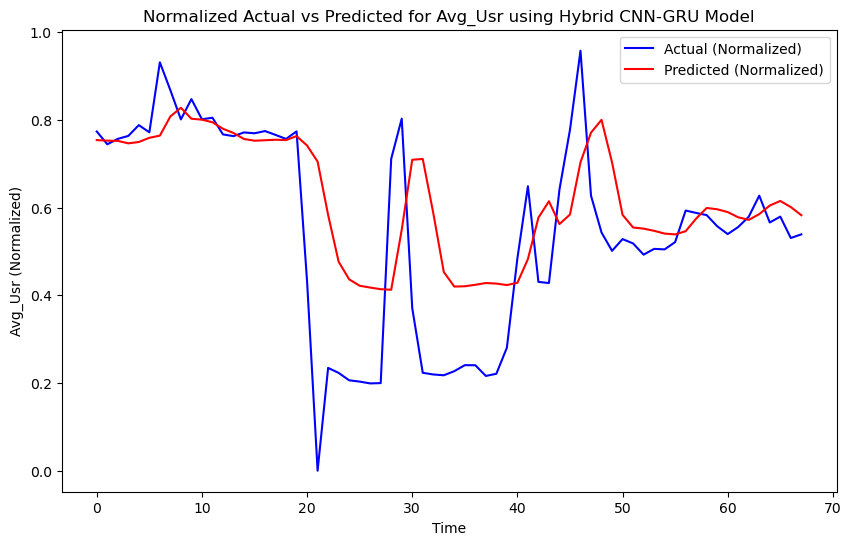

In [41]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for CNN-GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for CNN-GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for CNN and GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define the CNN-GRU model
def build_cnn_gru_model(input_shape):
    model = Sequential()
    
    # 1D CNN layers
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # GRU layers
    model.add(GRU(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    
    # Dense output layer
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train CNN-GRU model
cnn_gru_model = build_cnn_gru_model((look_back, 2))
cnn_gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the CNN-GRU model
train_predict_gru = cnn_gru_model.predict(X_train_gru)
test_predict_gru = cnn_gru_model.predict(X_test_gru)

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Hybrid CNN-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()